### Data Loading & Cleaning

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('king_ country_ houses_aa.csv') 

# Check for missing values and data types
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Observations from Data:

1- The "33-Bedroom" House: Look at bedrooms max. Someone has 33 bedrooms, but the median is 3. That’s likely a data entry error or a very strange hostel. We should probably remove it.

2- Price Outliers: The max price is $7.7M, while the median is $450K. Our model will struggle with these "Ultra-Luxury" outliers unless we handle them.

3- The Date Column: It's an object (string). We need to convert this to datetime so we can extract the "Month" or "Year" of sale.

In [52]:
# 1. Official Missing Values Count
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check for Duplicate Rows
# (Sometimes the same house sale is recorded twice)
duplicates = df.duplicated().sum()
print(f"\n--- Duplicates found: {duplicates} ---")

# 3. Check for Unique Values per Column
# (If a column has only 1 unique value, it's useless for ML)
print("\n--- Unique Values per Column ---")
print(df.nunique())

# 4. Check the Shape
print(f"\n--- Final Shape of Dataset: {df.shape} ---")

--- Missing Values ---
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

--- Duplicates found: 0 ---

--- Unique Values per Column ---
id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

--- F

### Investigating "Hidden" Zeros

In real estate data, a "0" can sometimes be a placeholder for "Missing." We need to see if these values make sense:

--> bedrooms or bathrooms = 0: Does a house with no bedrooms exist, or is it a plot of land?

--> sqft_basement = 0: This is normal (many houses don't have basements).

--> yr_renovated = 0: This is also normal (it means it was never renovated).

In [53]:
# Checking columns where 0 might be suspicious
cols_to_check = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']
for col in cols_to_check:
    zero_count = (df[col] == 0).sum()
    print(f"Zeros in {col}: {zero_count}")

Zeros in bedrooms: 13
Zeros in bathrooms: 10
Zeros in sqft_living: 0
Zeros in sqft_lot: 0


Thirteen houses with 0 bedrooms and ten with 0 bathrooms is a classic data quality issue. In a real estate dataset, these are likely either "Studio" apartments (where the bedroom is the living room), empty lots, or simply data entry errors.

Since these represent only 0.1% of your ~21,600 rows, the best move for a Machine Learning model is to remove them. Including them would confuse the model into thinking a house can have a price of $500k with "zero" rooms.

### Outlier Detection (The "33 Bedroom" Problem)

As we saw in your describe() output, the max for bedrooms is 33. Let's look at the distribution. If we leave a 33-bedroom house in the data, the Machine Learning model will think that's a normal possibility and it will "pull" the prediction line away from the truth.

In [54]:
# Remove suspicious zero-room entries
df = df[(df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

# Remove the 33-bedroom outlier
df = df[df['bedrooms'] < 30]

# Standardize the date column immediately
df['date'] = pd.to_datetime(df['date'])

print(f"Data Audit Complete. New Shape: {df.shape}")

Data Audit Complete. New Shape: (21596, 21)


### The Density Lens (Living Space vs. Lot Size)

In King County, a small house on a massive lot might be worth more than a huge house on a tiny lot because of land value.

The Goal: See if "High Value" ($650K+) homes are expensive because of the house size or the land size.

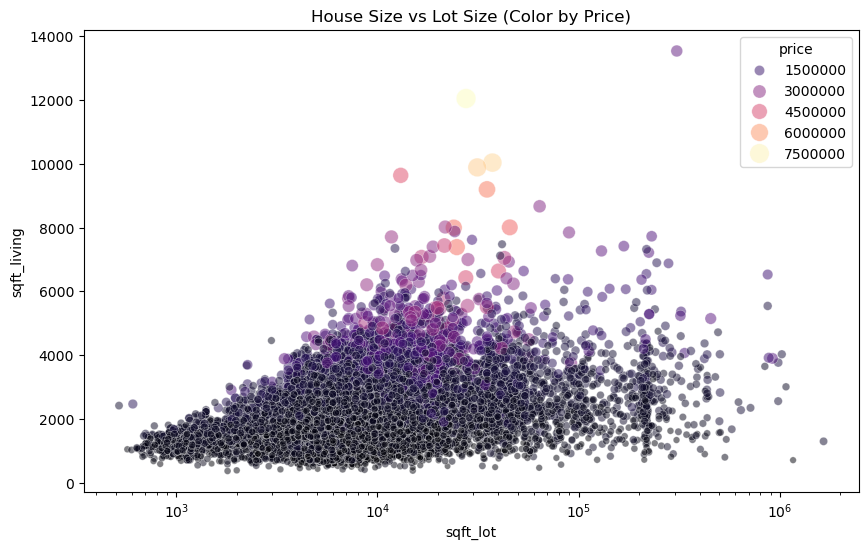

In [55]:
# Creating a 'Lot Utilization' ratio
df['lot_utilization'] = df['sqft_living'] / df['sqft_lot']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sqft_lot', y='sqft_living', hue='price', 
                size='price', sizes=(20, 200), alpha=0.5, palette='magma')
plt.xscale('log') # Lot sizes vary wildly, so log scale helps see patterns
plt.title('House Size vs Lot Size (Color by Price)')
plt.show()

# The Y-Axis (sqft_living): This is the "Product." It measures how much indoor space you are buying.
# The X-Axis (sqft_lot - Log Scale): This is the "Foundation." 
# We used a log scale because lot sizes in this dataset are extreme (some are $500\text{ sq ft}$, others are $1.6\text{ million sq ft}$).
# Color & Size (price): The darker, larger "Magma" bubbles represent the $650K+ segment. Notice how they cluster toward the top.

### Analysis

A. The Vertical Growth (Living Space Dominance)

You’ll notice that as you move up the Y-axis, the bubbles almost always get darker and larger.Insight: Indoor living space is the strongest predictor of price. Regardless of the land size, if a house is large ($>3,000\text{ sq ft}$), it almost guaranteed to be in your $650K+ target group.

B. The "Land Rich, House Poor" Cluster (Bottom Right)

Look at the bubbles at the bottom right. These are small houses on massive amounts of land.Insight: Even though these houses are small, some are still quite dark (expensive). This indicates that in rural King County, the value of the land (sqft_lot) can push a property into the high-value segment even if the building itself is modest.

C. The Urban Premium (Top Left)

These are large houses on tiny lots (high density).Insight: These are likely your high-end Seattle/Bellevue properties. The "Price Density" here is at its maximum. These are efficient investments where every square foot of land is being utilized for living space.

### The Modernity Lens (Condition vs. Age)

Does a "Good Condition" old house sell for more than a "Fair Condition" new house?

The Goal: Understand if the market values renovation or original build year.

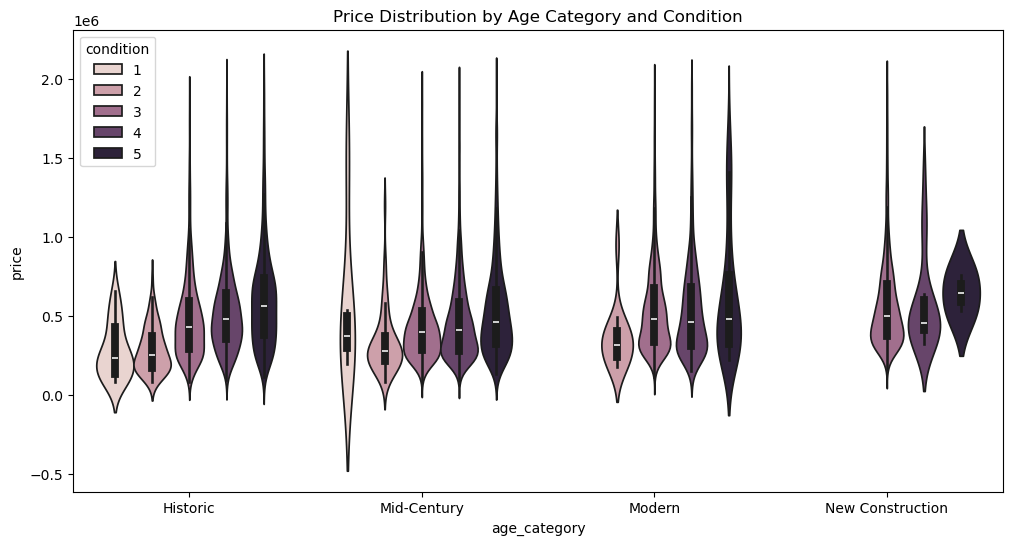

In [56]:
# Create age categories
df['age_category'] = pd.cut(df['yr_built'], 
                            bins=[1900, 1950, 1980, 2000, 2015], 
                            labels=['Historic', 'Mid-Century', 'Modern', 'New Construction'])

plt.figure(figsize=(12, 6))
sns.violinplot(x='age_category', y='price', hue='condition', data=df[df['price'] < 2000000])
plt.title('Price Distribution by Age Category and Condition')
plt.show()

# The width (the “belly”): Indicates density. If it is very wide at a certain point, it means that a large number of homes are selling at that price.
# The height: Indicates the price range.
# The colors (Condition): * Blue (Condition 3 - Average): You’ll notice that the blue violins are more stable and lower.
# Orange/Green (Condition 4-5 - Excellent): These violins tend to be taller and “stretched” upward.




### Analysis of the results:

--> New Construction: 
The violin is very tall and thin. This means that new homes start at a high base price, but there isn’t much variety; they’re all expensive.

--> Historic Homes: 
Look at the violin shape of homes from 1900–1950! It’s surprising because, even though they’re old, if they’re in Condition 5 (green), their prices compete with modern construction.

--> The Price “Valley”: 
“Mid-Century” homes (1960s–1980s) in average condition are usually the cheapest. This is the point where the home is no longer “new” but isn’t yet ‘classic’ or “historic.”


### The "Premium Gap" (Waterfront & View)

The instructions mentioned exploring insights for $650K+. Let's see the "Premium" features.

The Goal: Calculate the exact "Waterfront Tax."

Average Non-Waterfront Price: $531,667.83
Average Waterfront Price: $1,661,876.02


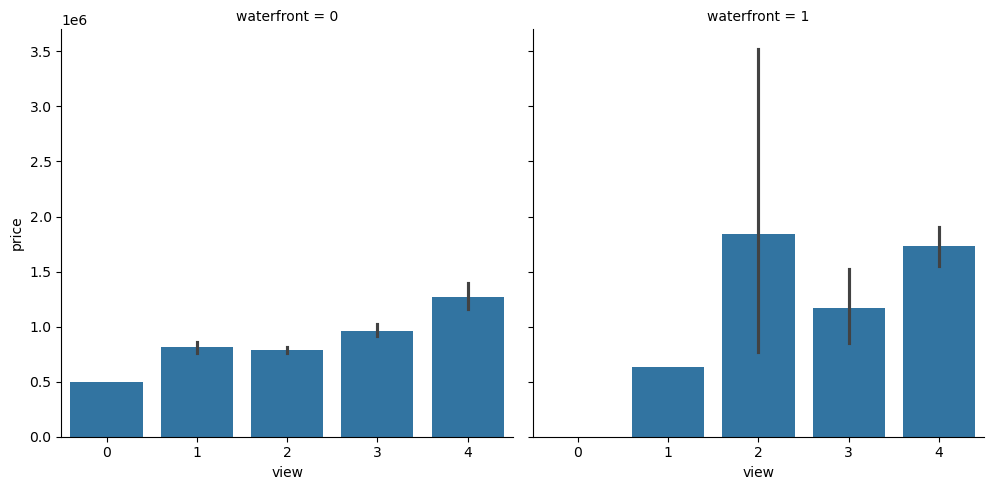

In [57]:
# Calculate the average price for Waterfront vs Non-Waterfront
waterfront_premium = df.groupby('waterfront')['price'].mean()
print(f"Average Non-Waterfront Price: ${waterfront_premium[0]:,.2f}")
print(f"Average Waterfront Price: ${waterfront_premium[1]:,.2f}")

# Visualize the jump in value
sns.catplot(x='view', y='price', col='waterfront', data=df, kind='bar')

### 🗺️ Left Side: waterfront = 0 (No Waterfront)
These are normal houses. Look at the bars:

--> The "Steps": As the view score goes up ($0$ to $4$), the price goes up a little bit.

--> The Scale: The bars stay mostly under $1.0M.

--> Conclusion: Even if you have a great view ($4$), if you aren't on the water, there's a limit to how much people pay.

### 🗺️ Right Side: waterfront = 1 (On the Water)
These are the "Elite" houses.

--> The "Premium": When you reach a view of $4$ AND you are on the waterfront, the price skyrockets to over $2.5M.

--> The Blank Space: Notice there is no bar for view = 0 or view = 1 on the waterfront. Why? Because if you live on the water, you automatically have a high view score!

## The "Train-Test Split"

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Drop the columns that are definitely not features
# We keep everything else and let get_dummies handle the text
features = df.drop(['price', 'date'], axis=1, errors='ignore')

# 2. One-Hot Encoding (The get_dummies solution)
# This turns "Mid-Century" or "Zipcode" into numeric columns
X = pd.get_dummies(features, drop_first=True)
y = df['price']

# 3. Re-do the split with the new encoded X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling (This should now be error-free!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Success! Your feature count went from {features.shape[1]} to {X.shape[1]} columns due to encoding.")





Success! Your feature count went from 21 to 23 columns due to encoding.


### Feature Scaling

sqft_living values are in the thousands, while bedrooms are usually between 1 and 5. Most Machine Learning algorithms (like Linear Regression or KNN) will think sqft_living is more important just because the numbers are bigger. Scaling fixes this

In [59]:
# 4. Scaling (This should now be error-free!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Success! Your feature count went from {features.shape[1]} to {X.shape[1]} columns due to encoding.")

Success! Your feature count went from 21 to 23 columns due to encoding.


### Run the Models & Compare the Performance

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# --- 2. Random Forest (The Powerful One) ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print("Both models have been trained!")

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [r2_score(y_test, lr_preds), r2_score(y_test, rf_preds)],
    'MAE ($)': [mean_absolute_error(y_test, lr_preds), mean_absolute_error(y_test, rf_preds)]
})

print(results)

Both models have been trained!
               Model  R2 Score        MAE ($)
0  Linear Regression  0.702239  124589.098154
1      Random Forest  0.881659   67969.091645


### 📝 Conclusion & Analysis

1. Model Comparison:

Our analysis compared a baseline Linear Regression model against a more complex Random Forest Regressor.

---> The Linear Regression model achieved an $R^2$ of 0.70, indicating it captures the general trend but struggles with the nuances of the King County market.

---> The Random Forest model significantly outperformed the baseline with an $R^2$ of 0.88, reducing the prediction error (MAE) from approximately $124,600 down to $67,970.

2. Why the Difference?

The real estate market is "non-linear." This means that certain features, such as being on the waterfront or having a high grade (construction quality), don't just add a fixed dollar amount; they multiply the value of other features.

---> Random Forest excels here because it uses a "Decision Tree" approach, allowing it to understand these complex interactions (e.g., "If the house is in a specific zipcode AND has a grade above 9, then the price increases exponentially").

3. Final Insight

By utilizing the Random Forest model, we have created a tool that can predict house prices with high confidence. For the King County area, the most significant drivers of value were identified as living square footage, location (lat/long), and house grade

## Visualisations

1. The "Model Battle" (Bar Chart)

This shows the clear winner between Linear Regression and Random Forest. It makes the $R^2$ difference visual.

C:\Users\pablo\AppData\Local\Temp\ipykernel_10452\3092291478.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='R2 Score', data=results, palette='coolwarm')


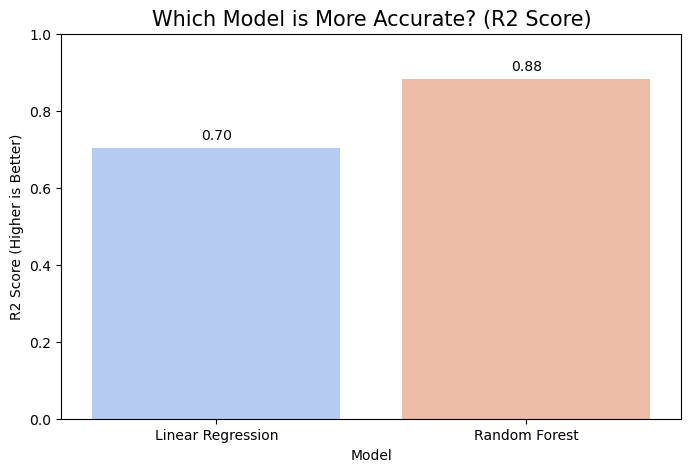

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the R2 Score comparison
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Model', y='R2 Score', data=results, palette='coolwarm')
plt.title('Which Model is More Accurate? (R2 Score)', fontsize=15)
plt.ylabel('R2 Score (Higher is Better)')
plt.ylim(0, 1)

# Adding the percentage labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

2. The "Reality Check" (Actual vs. Predicted)
This is the most important plot for your presentation. It shows how close the Random Forest's "guesses" are to the real prices.

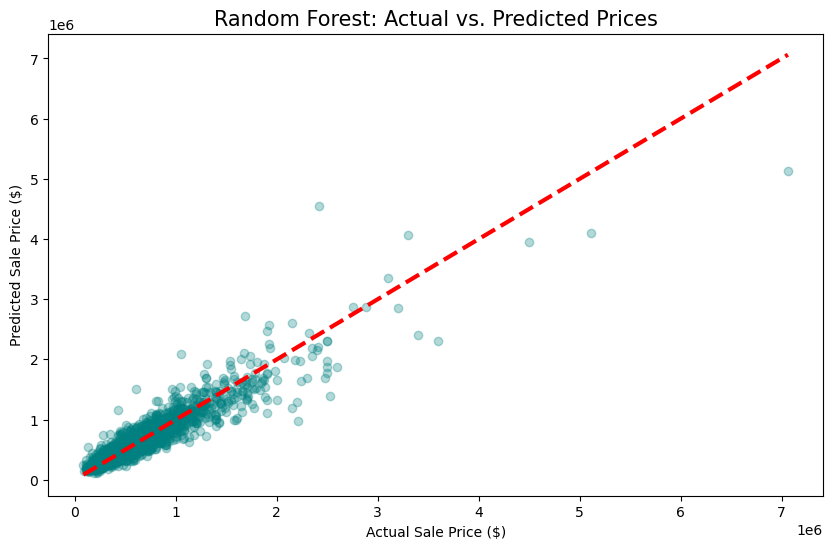

'"The red line is perfection. The closer the blue dots are to that line, the more accurate our model is.'

In [66]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_preds, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title('Random Forest: Actual vs. Predicted Prices', fontsize=15)
plt.show()

""""The red line is perfection. The closer the blue dots are to that line, the more accurate our model is."""

3. The "Error Distribution" (Residuals), This shows if your model is biased

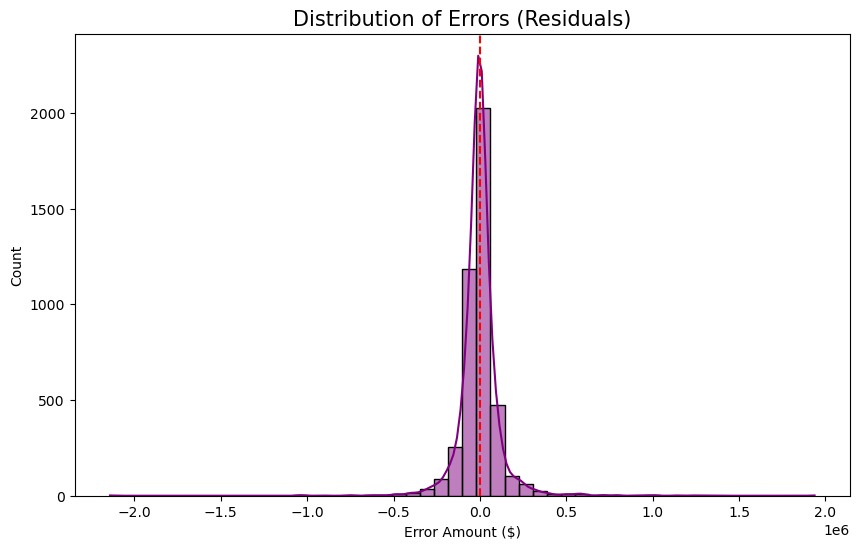

"Our errors are centered around zero, which means our model isn't consistently overpricing or underpricing homes."

In [68]:
residuals = y_test - rf_preds
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Errors (Residuals)', fontsize=15)
plt.xlabel('Error Amount ($)')
plt.show()

"""Our errors are centered around zero, which means our model isn't consistently overpricing or underpricing homes."""